In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from typing import *
from itertools import product

In [62]:
df_all = pd.read_csv('test_results.csv', encoding='UTF-8')
print(tabulate(df_all.head(10), headers=df_all.columns))

TYPES = df_all['GraphType'].unique()
DENSITIES = df_all['Density'].unique()

def graph_name_to_pl(g_type:str) -> str:
    if g_type == "Edge":
        return "Lista krawędzi"
    elif g_type == "List":
        return "Lista sąsiedztwa"
    elif g_type == "Matrix":
        return "Macierz sąsiedztwa"
    else:
        raise ValueError(f"Unknown graph type: {g_type}") 

      Rep    Size    Density  GraphType      CreationTime    SizeInBytes    GetWeightTimeMs    SetConnectionTimeMs
--  -----  ------  ---------  -----------  --------------  -------------  -----------------  ---------------------
 0      0     100       0.25  Edge               0.001568          60032           0.007342               0.005544
 1      0     100       0.25  List               0.001283          40824           0.000261               0.000295
 2      0     100       0.25  Matrix             0.044128          40824           6.1e-05                7.3e-05
 3      0     100       0.5   Edge               0.00062          120032           0.004168               0.014747
 4      0     100       0.5   List               0.001318          80824           0.000247               0.000429
 5      0     100       0.5   Matrix             0.0623            40824           9.1e-05                4.7e-05
 6      0     100       0.75  Edge               0.000742         180032          

In [63]:
df_gr = df_all.groupby(['Size', 'Density', 'GraphType']).agg(
    CreationTimeMsAvg = ('CreationTime', 'mean'),
    CreationTimeMsStd = ('CreationTime', 'std'),
    SizeInBytesAvg = ('SizeInBytes', 'mean'),
    SizeInBytesStd = ('SizeInBytes', 'std'),
    GetWeightTimeMs = ('GetWeightTimeMs', 'mean'),
    GetWeightTimeMsStd = ('GetWeightTimeMs', 'std'),
    SetConnectionTimeMs = ('SetConnectionTimeMs', 'mean'),
    SetConnectionTimeMsStd = ('SetConnectionTimeMs', 'std'),
).reset_index()

print(tabulate(df_gr.head(10), headers=df_gr.columns))

      Size    Density  GraphType      CreationTimeMsAvg    CreationTimeMsStd    SizeInBytesAvg    SizeInBytesStd    GetWeightTimeMs    GetWeightTimeMsStd    SetConnectionTimeMs    SetConnectionTimeMsStd
--  ------  ---------  -----------  -------------------  -------------------  ----------------  ----------------  -----------------  --------------------  ---------------------  ------------------------
 0     100       0.25  Edge                  0.00134016          0.00251883              60032                 0         0.007719             0.00338052              0.00720044               0.00137858
 1     100       0.25  List                  0.00126356          0.000196372             40824                 0         0.0002022            4.62565e-05             0.0002978                0.000124727
 2     100       0.25  Matrix                0.0427151           0.016454                40824                 0         7.492e-05            2.47738e-05             5.004e-05              

In [64]:
def prepare_df_per_experiment(df: pd.DataFrame, org_cols: List[str], measurement_name: str):
    df =  df.pivot_table(
        index=['Size', 'Density'], 
        columns='GraphType', 
        values=org_cols
    ).reset_index()
    
    df.columns = ['Size', 'Density', 
                  f'Edge{measurement_name}Avg', f'List{measurement_name}Avg', f'Matrix{measurement_name}Avg', 
                  f'Edge{measurement_name}Std', f'List{measurement_name}Std', f'Matrix{measurement_name}Std']
    df = df[['Size', 'Density',
             f'Edge{measurement_name}Avg', f'Edge{measurement_name}Std',
             f'List{measurement_name}Avg', f'List{measurement_name}Std',
             f'Matrix{measurement_name}Avg', f'Matrix{measurement_name}Std'
             ]]
    print(f"DF: {measurement_name}")
    print(tabulate(df.head(), headers=df.columns))
    return df


df_create = prepare_df_per_experiment(df_gr, ['CreationTimeMsAvg', 'CreationTimeMsStd'], 'Create')
df_memory = prepare_df_per_experiment(df_gr, ['SizeInBytesAvg', 'SizeInBytesStd'], 'Memory')
df_find = prepare_df_per_experiment(df_gr, ['GetWeightTimeMs', 'GetWeightTimeMsStd'], 'Find')
df_add = prepare_df_per_experiment(df_gr, ['SetConnectionTimeMs', 'SetConnectionTimeMsStd'], 'Add')


DF: Create
      Size    Density    EdgeCreateAvg    EdgeCreateStd    ListCreateAvg    ListCreateStd    MatrixCreateAvg    MatrixCreateStd
--  ------  ---------  ---------------  ---------------  ---------------  ---------------  -----------------  -----------------
 0     100       0.25       0.00134016      0.00251883        0.00126356      0.000196372          0.0427151          0.016454
 1     100       0.5        0.00141356      0.0036563         0.00163104      0.00249944           0.0372029          0.0130629
 2     100       0.75       0.00079812      0.000275822       0.00167732      0.00258399           0.0364308          0.0115368
 3     200       0.25       0.00211124      0.00511076        0.0953937       0.0243658            0.294196           0.0405975
 4     200       0.5        0.00066404      0.000173118       0.159567        0.0338328            0.523448           0.0692155
DF: Memory
      Size    Density    EdgeMemoryAvg    EdgeMemoryStd    ListMemoryAvg    ListMem

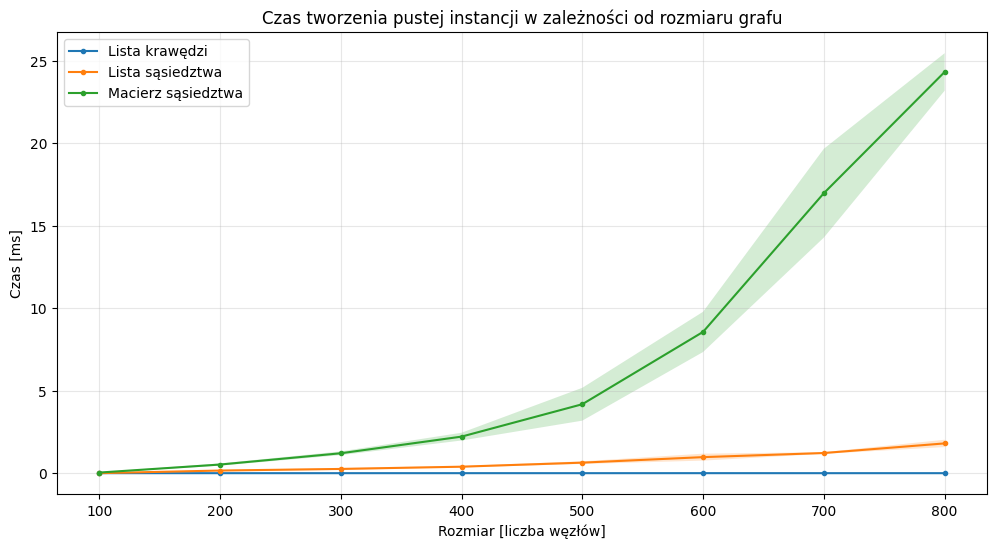

In [65]:
#! CREATION TIME

def creation_plot(df, measurement_name: str, graph_types: List[str], title: str, y_axis_name:str):
    fig, ax = plt.subplots(figsize=(12,6))
    
    df = df[df['Density']==0.5]
    
    for g_type in graph_types:
        label = f'{graph_name_to_pl(g_type)}'
        avg_col = f'{g_type}{measurement_name}Avg'
        std_col = f'{g_type}{measurement_name}Std'
        x = df["Size"]
        
        ax.plot(x, df[avg_col], marker='o', label=label, markersize=3)
        ax.fill_between(x, df[avg_col] - df[std_col], df[avg_col] + df[std_col], alpha=0.2)
    
    ax.set_title(title)
    ax.set_xlabel("Rozmiar [liczba węzłów]")
    ax.set_ylabel(y_axis_name)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.show()
    
creation_plot(df_create, 'Create', graph_types=TYPES, 
            title="Czas tworzenia pustej instancji w zależności od rozmiaru grafu",
            y_axis_name="Czas [ms]")


C:\Users\BPX Michał Dziedziak\AppData\Local\Temp\ipykernel_21548\2893829896.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


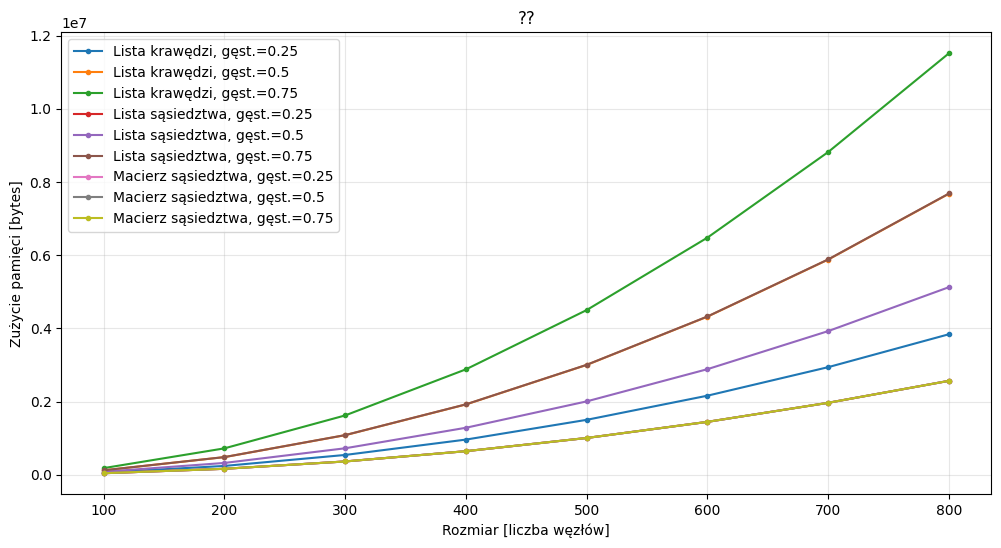

In [66]:
#! MEMORY USED
def memory_plot(df, measurement_name: str, graph_types: List[str], title: str, y_axis_name:str):
    fig, ax = plt.subplots(figsize=(12,6))
    
    for g_type, dens in product(graph_types, DENSITIES):
        sub_df = df[df["Density"] == dens]
        label = f'{graph_name_to_pl(g_type)}, gęst.={dens}'
        avg_col = f'{g_type}{measurement_name}Avg'
        std_col = f'{g_type}{measurement_name}Std'
        x = sub_df["Size"]
        
        ax.plot(x, sub_df[avg_col], marker='o', label=label, markersize=3)
        ax.fill_between(x, sub_df[avg_col] - sub_df[std_col], sub_df[avg_col] + sub_df[std_col], alpha=0.2)
    
    ax.set_title(title)
    ax.set_xlabel("Rozmiar [liczba węzłów]")
    ax.set_ylabel(y_axis_name)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    fig.show()

memory_plot(df_memory, 'Memory', graph_types=TYPES, 
            title="??",
            y_axis_name="Zużycie pamięci [bytes]")


C:\Users\BPX Michał Dziedziak\AppData\Local\Temp\ipykernel_21548\2014363669.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


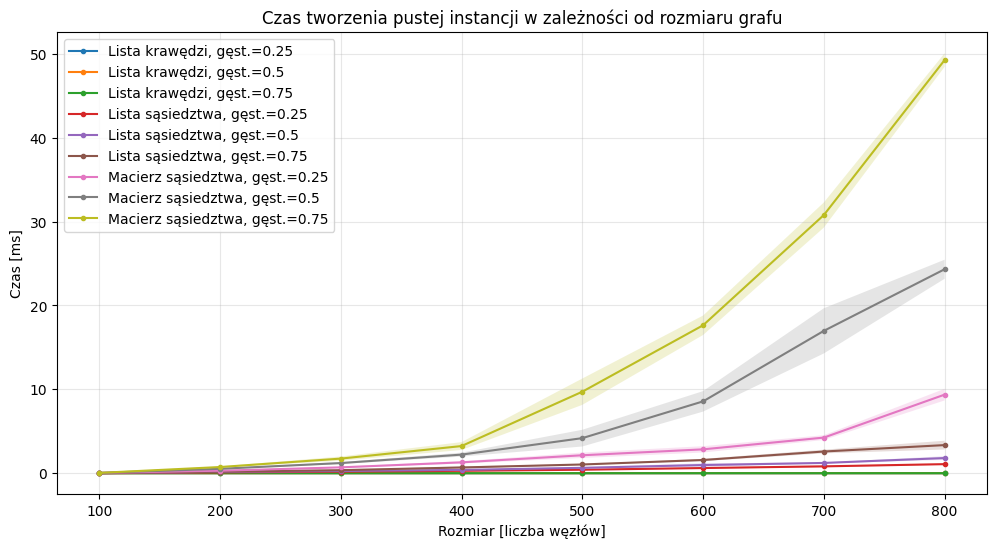

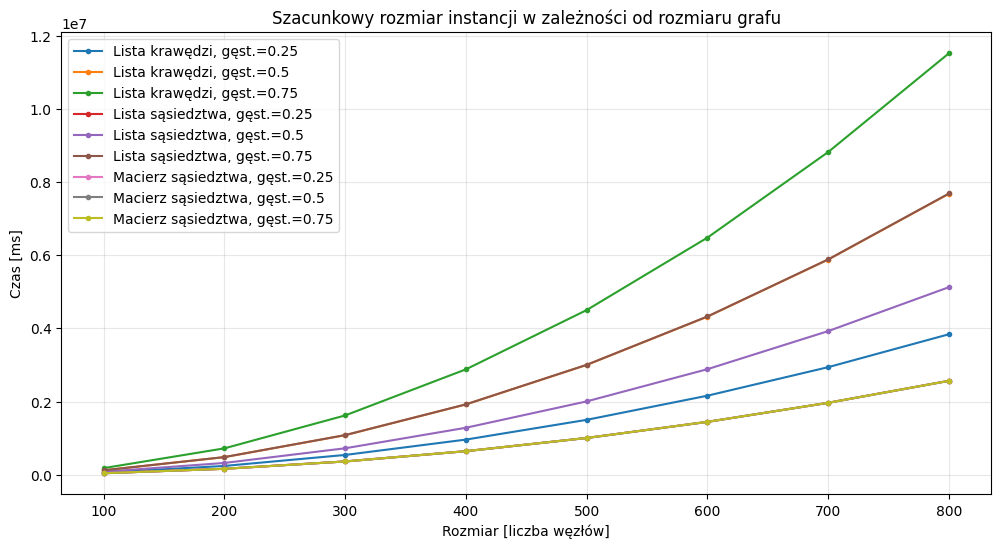

In [67]:
def create_plot(df, measurement_name: str, graph_types: List[str], title: str, y_axis_name:str):
    fig, ax = plt.subplots(figsize=(12,6))
    
    for g_type, dens in product(graph_types, DENSITIES):
        sub_df = df[df["Density"] == dens]
        label = f'{graph_name_to_pl(g_type)}, gęst.={dens}'
        avg_col = f'{g_type}{measurement_name}Avg'
        std_col = f'{g_type}{measurement_name}Std'
        x = sub_df["Size"]
        
        ax.plot(x, sub_df[avg_col], marker='o', label=label, markersize=3)
        ax.fill_between(x, sub_df[avg_col] - sub_df[std_col], sub_df[avg_col] + sub_df[std_col], alpha=0.2)
    
    ax.set_title(title)
    ax.set_xlabel("Rozmiar [liczba węzłów]")
    ax.set_ylabel(y_axis_name)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    fig.show()
    
# df_create = prepare_df_per_experiment(df_gr, ['CreationTimeMsAvg', 'CreationTimeMsStd'], 'Create')
# df_size = prepare_df_per_experiment(df_gr, ['SizeInBytesAvg', 'SizeInBytesStd'], 'Memory')
# df_find = prepare_df_per_experiment(df_gr, ['GetWeightTimeMs', 'GetWeightTimeMsStd'], 'Find')
# df_add = prepare_df_per_experiment(df_gr, ['SetConnectionTimeMs', 'SetConnectionTimeMsStd'], 'Add')
create_plot(df_create, 'Create', graph_types=TYPES, 
            title="Czas tworzenia pustej instancji w zależności od rozmiaru grafu",
            y_axis_name="Czas [ms]")

create_plot(df_size, 'Memory', graph_types=TYPES, 
            title="Szacunkowy rozmiar instancji w zależności od rozmiaru grafu",
            y_axis_name="Czas [ms]")